<a href="https://colab.research.google.com/github/carolsworld/NX_TSC/blob/main/NX_TSC_sktime_LSTMFCNClassifier_5Features_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Multivariate Time Series Prediction using LSTM-FCN on NX MCD Process Data

**This notebook demonstrates the development and application of a multivariate time series classification model using Long Short-Term Memory Fully Convolutional Networks (LSTM-FCN) from the sktime deep learning module to perform anomaly prediction on process data generated from Siemens NX MCD during a multi-stage attack simulation.**

#Objective of This Notebook


The goal of this notebook is to show the end-to-end process of applying LSTM-FCN on anomaly detection on process data, including
*   Data Preprocessing for Model Training and Evaluation
*   Model Training
*   Model Evaluation
*   Model Inference on the Multi-Stage Attack Simulated on 9 May 2025

# Background

A multi-stage cyber-physical attack simulation was conducted on 9 May 2025, between 14:34 and 17:02 (UK local time), using a Digital Twin-based testbed replicating a sorting process controlled within Siemens NX MCD. The testbed was integrated with HMI and OPC UA clients to simulate real-world adversarial behaviours targeting industrial actuators.

Out of the five attack steps, Step 3 and Step 5 involved manual manipulations of the physical process:

*   Step 3: Issued unauthorized commands through an HMI via RDP session.
*   Step 5: Executed unauthorized OPC UA write requests from UA Expert to the NX process.

These two steps are expected to exhibit anomalous actuator behaviours detectable in the process data. In contrast, Steps 1, 2, and 4 involved activities confined to host and network layers (e.g., discovery, lateral movement) and thus do not influence the process state directly.

# Overview of the Anomaly Detection Model

For anomaly detection on process data, we have identified 5 different scenarios in the NX scene. It could be a normal scenarios or threat scenarios. The scenario (being the label (y) to be predicted) include:

*   Label #0 - 'Normal_NoIntervention': Baseline operation without intervention.
*   Label #1 - 'Conveyor_SpeedManipulation':Speed forcibly reduced from standard (e.g., 300 to 50, or 50 to 10).
*   Label #2 - 'Gripper_SuctionForceRelease': Suction signal changed from 1 (hold) to 0 (release).
*   Label #3 - 'Gripper_ZAxisDirectionManipulation': Reverses Z-axis movement by forcing -400 (downward) instead of +400 (upward), and vice versa.
*   Label #4 - 'Gripper_RotationDeviation': Rotation angle forced to inappropriate value (e.g., 0° to 360°).
*   Label #5 - Multi-vector attacks of the above scenarios

## Simulation Process

For each scenario, we have carried out 10 simulation runs (i.e. 10 instances for each label). Therefore, there are tototally 60 simulation instances in the csv dataset. Each simulation run has 60 second of simulation.

The instance for Label #0 to #4 are used for model training, the instances for Label #5 are used for model evaluation.


##Data Capture Process

The NX MCD simulation was recorded using the Export function in the Runtime Inspector, with a sampling rate of 0.03 seconds. The data was manually exported into five separate CSV files, each corresponding to a different segment of the multi-stage simulation. Each row in the dataset represents a single timestamp, and 2000 timepoints roughly represent one minute of simulated activity.

During the simulation run, we used the export function of NX MCD to collect data. With a sampling rate of 0.03 second, in 1 minute of simulation, each instance is pre-processed in separate scripts to ensure the dataset used in this notebook only contain 2000 timepoints for each instance.

#Step 0 - Check GPU

To speed up the model training process, GPU is used.

In [1]:
# Turn on GPU T4

# Runtime > Change runtime type

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Mon May 12 12:53:41 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Step 1 - Upload dataset (csv file)

In [2]:
# Upload your csv file and check the number of rows and columns in the pandas dataframe
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded['NXdata_5ScenariosaddFeatures.csv']))

print("The number of rows and columns in the csv file: ", df.shape)

Saving NXdata_5ScenariosaddFeatures.csv to NXdata_5ScenariosaddFeatures.csv
The number of rows and columns in the csv file:  (100000, 8)


For reference, the timepoints is valued from '0' to value '1999'. Therefore, the number of row in the time-series dataset for model training is 2000 * 50 = 100,000 rows.

In [3]:
# Display the first few rows of the dataframe to check file format
df.head()

,instance,timepoint,MCD_GetBoxDone-value,GetBox_signal-value,Conveyor_Speed_AnyAbnormalFlag,Gripper_Z_Speed_CombinedAnomalyFlag,RotatePosition_CombinedAnomalyFlag,label
0,1,0,1.0,1.0,0,0,0,0
1,1,1,1.0,1.0,0,0,0,0
2,1,2,1.0,1.0,0,0,0,0
3,1,3,1.0,1.0,0,0,0,0
4,1,4,1.0,1.0,0,0,0,0


Regarding the columns on the dataset:
*   'instance' is instance identifier. There are 50 instance in this dataset.
*   'timepoints' is time series index for each instance. Every instance has 2000 timepoints (from value '0' to value '1999').
*    other than the above two columns and the 'label' column, the rest of the columns are the raw data from NX MCD and features to learn
*   'label' contains the labels of the instance, with value ranged from 0 to 4


# Step 2 - Dataset Preprocessing for Model Training and Evaluation

In [4]:
import numpy as np

# Set the index for multi-indexing
df = df.set_index(['instance', 'timepoint'])

# Sort the dataframe if not already sorted
df.sort_index(inplace=True)

In [5]:
# Calculate the number of instances and timepoints
num_instances = df.index.get_level_values(0).nunique()
num_timepoints = df.index.get_level_values(1).nunique()

In [6]:
print("Number of instances:", num_instances)
print("Number of timepoints:", num_timepoints)

Number of instances: 50
Number of timepoints: 2000


In [7]:
# Drop the 'label' column to get the features
X_features = df.drop(columns='label')

In [8]:
X_features

MCD_GetBoxDone-value  GetBox_signal-value  \
instance timepoint                                              
1        0                           1.0                  1.0   
         1                           1.0                  1.0   
         2                           1.0                  1.0   
         3                           1.0                  1.0   
         4                           1.0                  1.0   
...                                  ...                  ...   
50       1995                        1.0                  1.0   
         1996                        1.0                  1.0   
         1997                        1.0                  1.0   
         1998                        1.0                  1.0   
         1999                        1.0                  1.0   

                    Conveyor_Speed_AnyAbnormalFlag  \
instance timepoint                                   
1        0                                       0   
         1                                       0   
         2                                       0   
         3                                       0   
         4                                       0   
...                                            ...   
50       1995                                    0   
         1996                                    0   
         1997                                    0   
         1998                                    0   
         1999                                    0   

                    Gripper_Z_Speed_CombinedAnomalyFlag  \
instance timepoint                                        
1        0                                            0   
         1                                            0   
         2                                            0   
         3                                            0   
         4                                            0   
...                                                 ...   
50       1995                                         0   
         1996                                         0   
         1997                                         0   
         1998                                         0   
         1999                                         0   

                    RotatePosition_CombinedAnomalyFlag  
instance timepoint                                      
1        0                                           0  
         1                                           0  
         2                                           0  
         3                                           0  
         4                                           0  
...                                                ...  
50       1995                                        0  
         1996                                        0  
         1997                                        0  
         1998                                        0  
         1999                                        0  

[100000 rows x 5 columns]

In [9]:
# Print the shapes
print("Shape before reshaping:", X_features.shape)
print("Total expected size:", num_instances * 5 * num_timepoints)

Shape before reshaping: (100000, 5)
Total expected size: 500000


In [10]:
# Split the data into features (X) and labels (y):
# For this demonstration, there are 8 variables.
X = df.drop(columns='label').to_numpy().reshape(-1, 5, df.index.levels[1].size)
y = df['label'].to_numpy()

In [11]:
# Ensure labels are unique per instance and not per time point
# Reshape features (X) into a 3D numpy array
_, idx = np.unique(df.index.get_level_values(0), return_index=True)
y = y[idx]

In [12]:
X

array([[[1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 1.],
        [1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.]],

  

In [13]:
X.shape

(50, 5, 2000)

X is 3D array and should have the shape [number of samples, number of variables, sequence length].

Each of the 50 instances is a 2D array of 7 variables over 2000 timepoints

In [14]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4])

In [15]:
y.shape

(50,)

y is 1D numpy array with the shape [number of samples].

In [16]:
# Split the data into a training set and a test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=3, stratify=y)


In [17]:
X_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.],
        [0., 0., 1., ..., 1., 0., 0.],
        [1., 1., 1., ..., 1., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.]],

       [[0., 0., 1., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.]],

       ...,

       [[1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 1., 0., 0.],
        [0., 0., 1., ..., 1., 0., 0.],
        [0., 0., 1., ..., 1., 0., 0.],
        [0., 0., 1., ..., 1., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

  

In [18]:
X_test

array([[[1., 1., 0., ..., 0., 0., 0.],
        [1., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[1., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 1., 0.]],

       ...,

       [[1., 1., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 1., 0.]],

       [[1., 1., 0., ..., 1., 0., 0.],
        [1., 1., 1., ..., 0., 0., 0.],
        [1., 1., 0., ..., 1., 0., 0.],
        [1., 1., 1., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.]],

  

In [19]:
y_train

array([1, 2, 1, 1, 0, 2, 3, 1, 3, 4, 2, 4, 3, 4, 0, 3, 4, 4, 2, 0, 0, 1,
       1, 3, 3, 3, 4, 2, 0, 2, 4, 0, 1, 2, 0])

In [20]:
y_test

array([0, 2, 3, 3, 1, 0, 1, 4, 4, 2, 0, 2, 3, 1, 4])

# Step 3 - Train the model

In [21]:
# Install the sktime library
!pip install sktime
import sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.7/142.7 kB 14.8 MB/s eta 0:00:00


In [22]:
# Check in memory type is correct for label y
from sktime.datatypes import check_is_mtype
check_is_mtype(y, mtype="np.ndarray", return_metadata=True)

(True,
 '',
 {'is_empty': False,
  'is_univariate': True,
  'n_features': 1,
  'feature_names': [0],
  'dtypekind_dfip': [<DtypeKind.FLOAT: 2>],
  'feature_kind': [<DtypeKind.FLOAT: 2>],
  'is_equally_spaced': True,
  'has_nans': np.False_,
  'mtype': 'np.ndarray',
  'scitype': 'Series'})

In [23]:
import numpy as np
import seaborn as sns

from sktime.classification.deep_learning.lstmfcn import LSTMFCNClassifier

sns.set_style("whitegrid")

In [24]:
# Initialize the LSTMFCNClassifier
classifier = LSTMFCNClassifier()

In [25]:
# Fit the classifier on the training data
classifier.fit(X_train, y_train)

LSTMFCNClassifier()

# Step 4 - Prediction and Performance Analysis

In [26]:
# Predict the labels for the test set
y_pred = classifier.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step


In [27]:
# Calculate accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7333333333333333


In [28]:
# Check classification_report
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.75      1.00      0.86         3
           2       0.75      1.00      0.86         3
           3       0.75      1.00      0.86         3
           4       0.00      0.00      0.00         3

    accuracy                           0.73        15
   macro avg       0.58      0.73      0.65        15
weighted avg       0.58      0.73      0.65        15



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

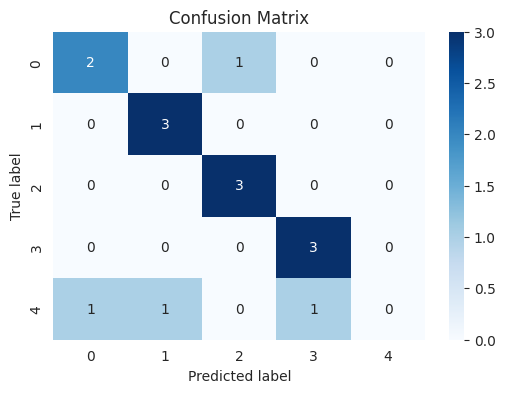

In [29]:
# Check confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap=plt.cm.Blues)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()


In [30]:
import pandas as pd

# Create a DataFrame showing instance index, true label, and predicted label
results_df = pd.DataFrame({
    'Instance Index': list(range(len(y_test))),
    'True Label': y_test,
    'Predicted Label': y_pred
})

# Show mismatches only
mismatches = results_df[results_df['True Label'] != results_df['Predicted Label']]

# Display the full or mismatched results
from IPython.display import display
display(mismatches)         # Only mismatches

,Instance Index,True Label,Predicted Label
5,5,0,2
7,7,4,1
8,8,4,3
14,14,4,0


The scenario (being the label (y) to be predicted) include:

*   Label #0 - 'Normal_NoIntervention': Baseline operation without intervention.
*   Label #1 - 'Conveyor_SpeedManipulation':Speed forcibly reduced from standard (e.g., 300 to 50, or 50 to 10).
*   Label #2 - 'Gripper_SuctionForceRelease': Suction signal changed from 1 (hold) to 0 (release).
*   Label #3 - 'Gripper_ZAxisDirectionManipulation': Reverses Z-axis movement by forcing -400 (downward) instead of +400 (upward), and vice versa.
*   Label #4 - 'Gripper_RotationDeviation': Rotation angle forced to inappropriate value (e.g., 0° to 360°).

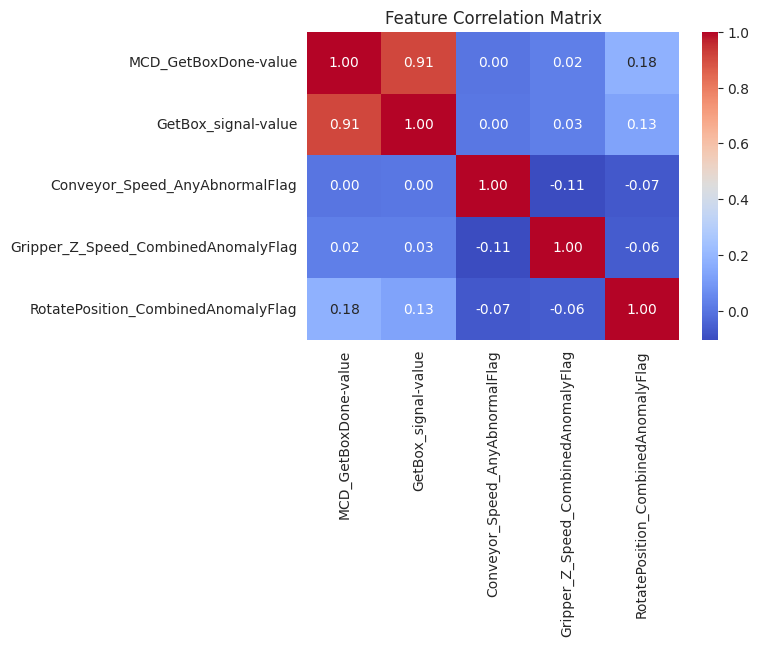

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

feature_cols = df.drop(columns=['instance', 'timepoint', 'label'], errors='ignore')
corr = feature_cols.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

# Step 5 - Save Trained Model and Evaluate on Unseen Multi-Vector Attack Data (Label 5)

In [32]:
# Save the sktime model wrapper (structure, hyperparameters, etc.)
classifier.save("NX_LSTMFCN_wrapper")

# Save the internal Keras model
classifier.model_.save("NX_LSTMFCN_keras.h5")

print("Model saved as 'NX_LSTMFCN_wrapper' and 'NX_LSTMFCN_keras.h5'")

Model saved as 'NX_LSTMFCN_wrapper' and 'NX_LSTMFCN_keras.h5'


In [33]:
classifier.model_.save("NX_LSTMFCN_keras.keras")

In [34]:
from google.colab import files
files.download("NX_LSTMFCN_keras.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
from google.colab import files
files.download("NX_LSTMFCN_keras.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Reminder: download the model from Google Colab file directory.

In [37]:
# Import untrained cases to evaluate the capability to identify mulit-vector attack
uploaded = files.upload()

filename = next(iter(uploaded))

df_unknown = pd.read_csv(io.BytesIO(uploaded['NXdata_UnknowncasesaddFeatures.csv']))

print("Shape of uploaded file:", df_unknown.shape)
df_unknown.head()

Saving NXdata_UnknowncasesaddFeatures.csv to NXdata_UnknowncasesaddFeatures.csv
Shape of uploaded file: (20000, 8)


,instance,timepoint,MCD_GetBoxDone-value,GetBox_signal-value,Conveyor_Speed_AnyAbnormalFlag,Gripper_Z_Speed_CombinedAnomalyFlag,RotatePosition_CombinedAnomalyFlag,label
0,51,0,0.0,0.0,0,0,0,5
1,51,1,0.0,0.0,0,0,0,5
2,51,2,0.0,0.0,0,0,0,5
3,51,3,0.0,0.0,0,0,0,5
4,51,4,0.0,0.0,0,0,0,5


In [38]:
df_unknown.shape

(20000, 8)

In [39]:
# Ensure same structure: multi-indexed by instance & timepoint
df_unknown = df_unknown.set_index(['instance', 'timepoint'])
df_unknown.sort_index(inplace=True)

# Drop the label column (optional, if present)
X_unknown = df_unknown.drop(columns=['label'], errors='ignore')

# Reshape into (n_instances, n_features, timepoints)
num_instances = X_unknown.index.get_level_values(0).nunique()
num_timepoints = X_unknown.index.get_level_values(1).nunique()
n_features = X_unknown.shape[1]

X_unknown = X_unknown.to_numpy().reshape(num_instances, n_features, num_timepoints)
print("New data shape:", X_unknown.shape)

New data shape: (10, 5, 2000)


In [40]:
y_pred_unknown = classifier.predict(X_unknown)
print("Predicted labels for unknown/multi-vector data:", y_pred_unknown)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
Predicted labels for unknown/multi-vector data: [1 3 4 1 4 2 2 2 1 2]


In [41]:
# Class descriptions
class_descriptions = {
    0: 'Label 0: Normal_NoIntervention',
    1: 'Label 1: Conveyor_SpeedManipulation',
    2: 'Label 2: Gripper_SuctionForceRelease',
    3: 'Label 3: Gripper_ZAxisDirectionManipulation',
    4: 'Label 4: Gripper_RotationDeviation'
}

# Attack information
known_attack_descriptions = [
    "Conveyor2_Speed, Conveyor3_Speed, GetBox_signal",
    "Gripper_Z_Speed, GetBox_signal",
    "Conveyor3_Speed, Gripper_Z_Speed",
    "Conveyor2_Speed, GetBox_signal",
    "Conveyor2_Speed, RotatePosition",
    "Gripper_Z_Speed, Conveyor3_Speed",
    "GetBox_signal, Gripper_Z_Speed",
    "Conveyor3_Speed, GetBox_signal",
    "Conveyor2_Speed, Gripper_Z_Speed",
    "GetBox_signal, RotatePosition"
]

In [42]:
if hasattr(classifier, "predict_proba"):
    y_proba = classifier.predict_proba(X_test)
    print("Prediction probabilities:\n", y_proba)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediction probabilities:
 [[9.99543965e-01 3.43328575e-05 2.35430285e-04 5.53859863e-05
  1.30894681e-04]
 [7.46162003e-03 2.12570463e-04 9.16673541e-01 7.55050406e-02
  1.47196362e-04]
 [1.07539201e-03 6.24041422e-04 1.80404373e-02 9.80108082e-01
  1.52048102e-04]
 [1.07499631e-03 1.30873714e-02 7.69558698e-02 9.07381237e-01
  1.50043285e-03]
 [7.48575767e-05 9.34079349e-01 5.20320726e-04 5.12872310e-03
  6.01966828e-02]
 [4.58480790e-02 6.25777582e-04 9.48015869e-01 1.16595533e-03
  4.34437022e-03]
 [3.62800029e-06 9.99992251e-01 9.20222533e-07 1.86174816e-06
  1.35037362e-06]
 [4.93074255e-03 9.36644077e-01 3.14042792e-02 9.25862044e-03
  1.77623108e-02]
 [6.22567348e-03 1.33186076e-02 1.22678140e-03 9.77030039e-01
  2.19890988e-03]
 [2.39276215e-02 9.00432569e-05 9.74653423e-01 9.03684879e-04
  4.25229839e-04]
 [9.99900579e-01 1.67995258e-05 4.10552493e-05 1.93510950e-05
  2.21857390e-05]
 [5.99131174e-03 4.82144833e-06 9.93956029e-01 4.517983

In [43]:
y_proba = classifier.predict_proba(X_unknown)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


In [44]:
import pandas as pd
from IPython.display import display

results = pd.DataFrame({
    'Instance': list(range(len(y_pred_unknown))),
    'Attack': known_attack_descriptions,
    'Predicted Label': y_pred_unknown,
    'Predicted Label Description': [class_descriptions[label] for label in y_pred_unknown]
})

for i in range(y_proba.shape[1]):
    results[f'Prob_Class_{i}'] = (y_proba[:, i] * 100).round(2).astype(str) + '%'

display(results)
results.to_csv('/content/NX_unknown_prediction_result_with_probability.csv', index=False)
print("Saved predictions with descriptions to CSV.")

,Instance,Attack,Predicted Label,Predicted Label Description,Prob_Class_0,Prob_Class_1,Prob_Class_2,Prob_Class_3,Prob_Class_4
0,0,"Conveyor2_Speed, Conveyor3_Speed, GetBox_signal",1,Label 1: Conveyor_SpeedManipulation,2.29%,90.45%,0.55%,5.22%,1.48%
1,1,"Gripper_Z_Speed, GetBox_signal",3,Label 3: Gripper_ZAxisDirectionManipulation,0.35%,7.03%,20.3%,71.01%,1.3%
2,2,"Conveyor3_Speed, Gripper_Z_Speed",4,Label 4: Gripper_RotationDeviation,0.0%,27.39%,0.0%,0.8%,71.81%
3,3,"Conveyor2_Speed, GetBox_signal",1,Label 1: Conveyor_SpeedManipulation,0.05%,99.66%,0.08%,0.19%,0.02%
4,4,"Conveyor2_Speed, RotatePosition",4,Label 4: Gripper_RotationDeviation,0.0%,2.11%,0.0%,0.02%,97.87%
5,5,"Gripper_Z_Speed, Conveyor3_Speed",2,Label 2: Gripper_SuctionForceRelease,0.79%,41.67%,57.16%,0.36%,0.02%
6,6,"GetBox_signal, Gripper_Z_Speed",2,Label 2: Gripper_SuctionForceRelease,0.0%,0.0%,99.97%,0.02%,0.01%
7,7,"Conveyor3_Speed, GetBox_signal",2,Label 2: Gripper_SuctionForceRelease,0.0%,20.92%,78.82%,0.24%,0.01%
8,8,"Conveyor2_Speed, Gripper_Z_Speed",1,Label 1: Conveyor_SpeedManipulation,0.03%,95.44%,0.01%,4.49%,0.02%
9,9,"GetBox_signal, RotatePosition",2,Label 2: Gripper_SuctionForceRelease,34.97%,0.0%,65.03%,0.0%,0.0%


Saved predictions with descriptions to CSV.


Reminder: download the results files from Google Colab file directory.

# Step 6 - Get the probabilities for all 60 instances for fusion with network data


In [48]:
import pandas as pd

# Directly read the CSV from file system
df_all = pd.read_csv("NXdata_5ScenariosaddFeatures_60instances.csv")

# show shape or head
print("Loaded file shape:", df_all.shape)
df_all.head()

Loaded file shape: (120000, 8)


,instance,timepoint,MCD_GetBoxDone-value,GetBox_signal-value,Conveyor_Speed_AnyAbnormalFlag,Gripper_Z_Speed_CombinedAnomalyFlag,RotatePosition_CombinedAnomalyFlag,label
0,1,0,1.0,1.0,0,0,0,0
1,1,1,1.0,1.0,0,0,0,0
2,1,2,1.0,1.0,0,0,0,0
3,1,3,1.0,1.0,0,0,0,0
4,1,4,1.0,1.0,0,0,0,0


In [49]:
# Preprocess All 60 Instances
df_all = df_all.set_index(['instance', 'timepoint'])
df_all.sort_index(inplace=True)

# Drop label column if needed (for inference only)
X_all = df_all.drop(columns=['label'], errors='ignore')

# Reshape into (n_instances, n_features, timepoints)
n_instances = X_all.index.get_level_values(0).nunique()
n_timepoints = X_all.index.get_level_values(1).nunique()
n_features = X_all.shape[1]

X_all_reshaped = X_all.to_numpy().reshape(n_instances, n_features, n_timepoints)

Reshapes data into a 3D tensor: [instances, features, timepoints], which is expected by the LSTMFCNClassifier.

In [50]:
# Predict on all 60 reshaped instances
y_pred_all = classifier.predict(X_all_reshaped)
y_proba_all = classifier.predict_proba(X_all_reshaped)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


In [51]:
import pandas as pd

# Construct output DataFrame with Instance number and predicted label
result_df = pd.DataFrame({
    'Instance': list(range(1, len(y_pred_all) + 1)),
    'Predicted_Label': y_pred_all
})

# Add class probabilities
for i in range(y_proba_all.shape[1]):
    result_df[f'Prob_Class_{i}'] = (y_proba_all[:, i] * 100).round(2).astype(str) + '%'


def assign_ground_truth_label(instance):
    if 1 <= instance <= 10:
        return 0  # Normal_NoIntervention
    elif 11 <= instance <= 20:
        return 1  # Conveyor_SpeedManipulation
    elif 21 <= instance <= 30:
        return 2  # Gripper_SuctionForceRelease
    elif 31 <= instance <= 40:
        return 3  # Gripper_ZAxisDirectionManipulation
    elif 41 <= instance <= 50:
        return 4  # Gripper_RotationDeviation
    else:
        return 5  # Multi-vector (combined or unknown)

# Apply this to your dataframe
result_df['Ground Truth'] = result_df['Instance'].apply(assign_ground_truth_label)

label_desc = {
    0: 'Label 0: Normal_NoIntervention',
    1: 'Label 1: Conveyor_SpeedManipulation',
    2: 'Label 2: Gripper_SuctionForceRelease',
    3: 'Label 3: Gripper_ZAxisDirectionManipulation',
    4: 'Label 4: Gripper_RotationDeviation',
    5: 'Label 5: Multi_Vector_Combined'
}

result_df['Label_Description'] = result_df['Ground Truth'].map(label_desc)

# Save to CSV
result_df.to_csv("NX_process_predictions_all60_with_label.csv", index=False)

In [52]:
# Download the csv result
from google.colab import files
files.download("NX_process_predictions_all60_with_label.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
result_df

,Instance,Predicted_Label,Prob_Class_0,Prob_Class_1,Prob_Class_2,Prob_Class_3,Prob_Class_4,Ground Truth,Label_Description
0,1,0,99.99%,0.0%,0.0%,0.0%,0.0%,0,Label 0: Normal_NoIntervention
1,2,0,99.99%,0.0%,0.01%,0.0%,0.0%,0,Label 0: Normal_NoIntervention
2,3,0,99.98%,0.0%,0.01%,0.0%,0.01%,0,Label 0: Normal_NoIntervention
3,4,2,4.58%,0.06%,94.8%,0.12%,0.43%,0,Label 0: Normal_NoIntervention
4,5,0,100.0%,0.0%,0.0%,0.0%,0.0%,0,Label 0: Normal_NoIntervention
5,6,0,100.0%,0.0%,0.0%,0.0%,0.0%,0,Label 0: Normal_NoIntervention
6,7,0,99.99%,0.0%,0.01%,0.0%,0.0%,0,Label 0: Normal_NoIntervention
7,8,0,99.99%,0.0%,0.0%,0.0%,0.0%,0,Label 0: Normal_NoIntervention
8,9,0,99.95%,0.0%,0.02%,0.01%,0.01%,0,Label 0: Normal_NoIntervention
9,10,0,100.0%,0.0%,0.0%,0.0%,0.0%,0,Label 0: Normal_NoIntervention


# Step 7 – Inference on Multi-Stage Attack Simulation (9 May 2025)

This step loads the saved `NX_LSTMFCN_final.pkl` model and applies it to process data from the multi-stage attack simulation, covering 98 instances from 14:39 to 17:02. Predictions and class probabilities are generated to support decision fusion.


*   Preprocess the five exported CSV files into one unified dataset containing only 1-minute segments (i.e., 2000 timepoints per instance).
*   Apply the LSTM-FCN model trained on process-only data to generate per-minute anomaly scores.
*   Flag instances with detected anomalies corresponding to Step 3 and Step 5 of the attack chain.
*   Export the result as prediction_ready.csv, which will be used for decision fusion with concurrent network and host-based anomaly scores.

A supplementary file timeline_reference.csv is also created to keep track of timestamps for all 1-minute segments, including those where no process data was available, for transparency and completeness in multimodal analysis.


Due to NX’s memory constraints and the manual nature of data export, several gaps exist between these files. To reconstruct accurate timing:

*   File creation timestamps were used as factual reference points for the end time of each recording.
*   Start times were deduced using the sampling rate and the number of rows in each file.
*   A detailed reconstruction of timestamps ensures proper alignment between process data and other modalities (e.g., OPC UA traffic, Wazuh host logs)

In [54]:
# Upload csv file and check the number of rows and columns in the pandas dataframe
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))

df_09May = pd.read_csv(io.BytesIO(uploaded['prediction_ready.csv']))

print("The number of rows and columns in the csv file: ", df_09May.shape)


Saving prediction_ready.csv to prediction_ready.csv
The number of rows and columns in the csv file:  (196000, 9)


Expected number of row is 196,000 with 9 columns.

In [56]:
from pathlib import Path
from sktime.classification.deep_learning.base import BaseDeepClassifier
from tensorflow.keras.models import load_model
import shutil

# Prepare path
model_path = Path("NX_LSTMFCN_wrapper.zip")

# Load sktime wrapper from .zip
loaded_model = BaseDeepClassifier.load_from_path(model_path)

# Inject trained Keras model
loaded_model.model_ = load_model("NX_LSTMFCN_keras.h5")

print("Model loaded successfully.")

Model loaded successfully.


In [57]:
df_09May.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196000 entries, 0 to 195999
Data columns (total 9 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   instance                             196000 non-null  int64  
 1   timepoint                            196000 non-null  int64  
 2   approx_time                          196000 non-null  object 
 3   MCD_GetBoxDone-value                 196000 non-null  float64
 4   GetBox_signal-value                  196000 non-null  float64
 5   Conveyor_Speed_AnyAbnormalFlag       196000 non-null  int64  
 6   Gripper_Z_Speed_CombinedAnomalyFlag  196000 non-null  int64  
 7   RotatePosition_CombinedAnomalyFlag   196000 non-null  int64  
 8   minute                               196000 non-null  object 
dtypes: float64(2), int64(5), object(2)
memory usage: 13.5+ MB


Regarding the columns on the dataset:
*   'instance' is instance identifier. There are 98 instance in this dataset.
*   'timepoint' is time series index for each instance. Every instance has 2000 timepoints (from value '0' to value '1999').
*   'approx_time' is the time deduced from the file creation time of the CSV file during process data export
*   'minute' is the timestamp for correlating with OPC UA network anomaly and host anomaly

The rest of the colunns represent the features learned by the model.




The purpose of this step is to apply the trained LSTM-FCN model to unseen process data collected during a multi-stage cyber-physical attack simulation conducted on 9 May 2025. This data includes 98 instances of 1-minute process behavior (each with 2000 timepoints), recorded during periods of both benign operation and simulated malicious intervention via OPC UA clients.

The goal is to:
- Assess whether the model can detect anomalies during Step 3 and Step 5 (where actuator manipulations were issued).
- Validate whether the model avoids false positives during Step 1, 2, and 4.
- Export the predicted labels and class probabilities for fusion with OPC UA and host-based anomaly detections.


##Dataset preprocessing

In [58]:
# Set multi-index and sort
df_09May = df_09May.set_index(['instance', 'timepoint'])
df_09May.sort_index(inplace=True)

In [59]:
# Drop non-feature columns (optional but recommended)
X_09May = df_09May.drop(columns=['label', 'minute', 'approx_time'], errors='ignore')

In [60]:
# Extract dimensions
n_instances = X_09May.index.get_level_values(0).nunique()
n_timepoints = X_09May.index.get_level_values(1).nunique()
n_features = X_09May.shape[1]

In [61]:
# Reshape to 3D array
X_09May = X_09May.to_numpy().reshape(n_instances, n_features, n_timepoints)
print(f"X_09May shape: {X_09May.shape}")

X_09May shape: (98, 5, 2000)


 ## Inference with Trained Model

In [62]:
y_pred_09May = loaded_model.predict(X_09May)
y_proba_09May = loaded_model.predict_proba(X_09May)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 769ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


In [63]:
# === Construct instance-level result with minute reference ===

# Extract the minute for each instance from df_09May
minutes_per_instance = df_09May.reset_index().groupby('instance')['minute'].first().reset_index()

# Build result dataframe
df_results_09May = pd.DataFrame({
    'Instance': list(range(n_instances)),
    'Minute': minutes_per_instance['minute'],
    'Predicted_Label': y_pred_09May
})

# Add probability per class
for i in range(y_proba_09May.shape[1]):
    df_results_09May[f'Prob_Class_{i}'] = (y_proba_09May[:, i] * 100).round(2).astype(str) + '%'

# Add label descriptions
label_desc = {
    0: 'Label 0: Normal_NoIntervention',
    1: 'Label 1: Conveyor_SpeedManipulation',
    2: 'Label 2: Gripper_SuctionForceRelease',
    3: 'Label 3: Gripper_ZAxisDirectionManipulation',
    4: 'Label 4: Gripper_RotationDeviation',
    5: 'Label 5: Multi_Vector_Combined'
}

df_results_09May['Label_Description'] = df_results_09May['Predicted_Label'].map(label_desc)

# Save to CSV
df_results_09May.to_csv('/content/NX_predictions_09May_instances_with_minute.csv', index=False)
print("✅ Saved instance-level predictions with minute column.")

✅ Saved instance-level predictions with minute column.


In [64]:
# Get the probabilities for all 98 instances for fusion with network data
df_results_09May

,Instance,Minute,Predicted_Label,Prob_Class_0,Prob_Class_1,Prob_Class_2,Prob_Class_3,Prob_Class_4,Label_Description
0,0,2025-05-09 14:39:00,0,100.0%,0.0%,0.0%,0.0%,0.0%,Label 0: Normal_NoIntervention
1,1,2025-05-09 14:40:00,0,100.0%,0.0%,0.0%,0.0%,0.0%,Label 0: Normal_NoIntervention
2,2,2025-05-09 14:41:00,0,99.93%,0.0%,0.06%,0.0%,0.0%,Label 0: Normal_NoIntervention
3,3,2025-05-09 14:42:00,0,100.0%,0.0%,0.0%,0.0%,0.0%,Label 0: Normal_NoIntervention
4,4,2025-05-09 14:43:00,0,99.98%,0.0%,0.01%,0.0%,0.0%,Label 0: Normal_NoIntervention
...,...,...,...,...,...,...,...,...,...
93,93,2025-05-09 16:57:00,0,94.82%,4.64%,0.12%,0.25%,0.18%,Label 0: Normal_NoIntervention
94,94,2025-05-09 16:58:00,1,0.01%,99.78%,0.01%,0.02%,0.19%,Label 1: Conveyor_SpeedManipulation
95,95,2025-05-09 16:59:00,1,0.01%,99.42%,0.0%,0.01%,0.55%,Label 1: Conveyor_SpeedManipulation
96,96,2025-05-09 17:00:00,4,0.0%,0.13%,0.01%,0.02%,99.84%,Label 4: Gripper_RotationDeviation


#Step 8 - Correlate with Alarm Log from Data Historian for 9 May 2025 Activities

Correlate the alarm event logs from PostgreSQL

In [65]:
# Upload csv file and check the number of rows and columns in the pandas dataframe
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))

df_alarm = pd.read_csv(io.BytesIO(uploaded['20250509_AlarmLogs_9May.csv']))

print("The number of rows and columns in the csv file: ", df_alarm.shape)


Saving 20250509_AlarmLogs_9May.csv to 20250509_AlarmLogs_9May.csv
The number of rows and columns in the csv file:  (17, 6)


In [66]:
import pandas as pd
from datetime import datetime

# Load alarm data
df_alarm = pd.read_csv('/content/20250509_AlarmLogs_9May.csv')

# Convert eventtime to datetime
df_alarm['eventtime'] = pd.to_datetime(df_alarm['eventtime'])

# Define reference time (can match to earliest or known moment)
reference_time = datetime.strptime("2025-05-09 15:59:14", "%Y-%m-%d %H:%M:%S")

# Calculate the instance number (0-based minute index)
df_alarm['instance'] = ((df_alarm['eventtime'] - reference_time).dt.total_seconds() // 60).astype(int)

# Add 'minute' string format
df_alarm['Minute'] = df_alarm['eventtime'].dt.floor('min')

# Verify
df_alarm.head()

,eventtime,source,priority,eventtype,eventflags,floatvalue,instance,Minute
0,2025-05-09 15:59:13.891,prov:default:/tag:Conveyor2_Speed:/alm:High Sp...,1,0,0,432.0,-1,2025-05-09 15:59:00
1,2025-05-09 15:59:17.933,prov:default:/tag:Conveyor2_Speed:/alm:High Sp...,1,1,16,50.0,0,2025-05-09 15:59:00
2,2025-05-09 15:59:30.055,prov:default:/tag:Conveyor2_Speed:/alm:High Sp...,1,0,0,489.0,0,2025-05-09 15:59:00
3,2025-05-09 15:59:39.635,prov:default:/tag:Conveyor2_Speed:/alm:High Sp...,1,2,0,NaN,0,2025-05-09 15:59:00
4,2025-05-09 15:59:50.457,prov:default:/tag:Conveyor2_Speed:/alm:High Sp...,1,1,24,50.0,0,2025-05-09 15:59:00


In [67]:
df_alarm['eventtime'] = pd.to_datetime(df_alarm['eventtime'])
df_alarm['instance'] = (df_alarm['eventtime'] - reference_time).dt.total_seconds() // 60
df_alarm['instance'] = df_alarm['instance'].astype(int)

In [68]:
# Per-minute alarm summary - count the number of alarms per minute
df_alarm_summary = (
    df_alarm
    .groupby('Minute')
    .agg(
        alarm_count=('source', 'count'),
        high_priority_count=('priority', lambda x: (x >= 2).sum()),
        sources=('source', lambda x: ', '.join(set(x))),
        float_mean=('floatvalue', 'mean'),
        float_max=('floatvalue', 'max'),
        float_min=('floatvalue', 'min')
    )
    .reset_index()
)

In [69]:
# Alarm count, high-priority count, and a concatenated string of alarm sources
df_alarm_summary

,Minute,alarm_count,high_priority_count,sources,float_mean,float_max,float_min
0,2025-05-09 15:59:00,5,0,prov:default:/tag:Conveyor2_Speed:/alm:High Sp...,255.250000,489.0,50.0
1,2025-05-09 16:00:00,3,0,prov:default:/tag:Conveyor3_Speed:/alm:High Sp...,275.000000,500.0,50.0
2,2025-05-09 16:01:00,3,0,prov:default:/tag:Conveyor3_Speed:/alm:High Sp...,260.500000,471.0,50.0
3,2025-05-09 16:53:00,1,0,prov:default:/tag:Conveyor2_Speed:/alm:High Sp...,400000.000000,400000.0,400000.0
4,2025-05-09 16:54:00,3,0,prov:default:/tag:Conveyor2_Speed:/alm:High Sp...,13366.666667,40000.0,50.0
5,2025-05-09 16:57:00,2,0,prov:default:/tag:Conveyor3_Speed:/alm:High Sp...,20025.000000,40000.0,50.0


In [70]:
df_results_09May

,Instance,Minute,Predicted_Label,Prob_Class_0,Prob_Class_1,Prob_Class_2,Prob_Class_3,Prob_Class_4,Label_Description
0,0,2025-05-09 14:39:00,0,100.0%,0.0%,0.0%,0.0%,0.0%,Label 0: Normal_NoIntervention
1,1,2025-05-09 14:40:00,0,100.0%,0.0%,0.0%,0.0%,0.0%,Label 0: Normal_NoIntervention
2,2,2025-05-09 14:41:00,0,99.93%,0.0%,0.06%,0.0%,0.0%,Label 0: Normal_NoIntervention
3,3,2025-05-09 14:42:00,0,100.0%,0.0%,0.0%,0.0%,0.0%,Label 0: Normal_NoIntervention
4,4,2025-05-09 14:43:00,0,99.98%,0.0%,0.01%,0.0%,0.0%,Label 0: Normal_NoIntervention
...,...,...,...,...,...,...,...,...,...
93,93,2025-05-09 16:57:00,0,94.82%,4.64%,0.12%,0.25%,0.18%,Label 0: Normal_NoIntervention
94,94,2025-05-09 16:58:00,1,0.01%,99.78%,0.01%,0.02%,0.19%,Label 1: Conveyor_SpeedManipulation
95,95,2025-05-09 16:59:00,1,0.01%,99.42%,0.0%,0.01%,0.55%,Label 1: Conveyor_SpeedManipulation
96,96,2025-05-09 17:00:00,4,0.0%,0.13%,0.01%,0.02%,99.84%,Label 4: Gripper_RotationDeviation


In [71]:
df_results_09May.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Instance           98 non-null     int64 
 1   Minute             98 non-null     object
 2   Predicted_Label    98 non-null     int64 
 3   Prob_Class_0       98 non-null     object
 4   Prob_Class_1       98 non-null     object
 5   Prob_Class_2       98 non-null     object
 6   Prob_Class_3       98 non-null     object
 7   Prob_Class_4       98 non-null     object
 8   Label_Description  98 non-null     object
dtypes: int64(2), object(7)
memory usage: 7.0+ KB


In [72]:
df_results_09May['Minute'] = pd.to_datetime(df_results_09May['Minute'])

In [73]:
# df_results_09May are preserved, and then merge with the alarm count based on 'minute'
df_enriched = df_results_09May.merge(df_alarm_summary, on='Minute', how='left')

# Display as 0 if no alarm
df_enriched.fillna({'alarm_count': 0, 'high_priority_count': 0, 'sources': 'None'}, inplace=True)

# Save enriched version
df_enriched.to_csv('/content/NX_predictions_09May_instances_with_alarms.csv', index=False)

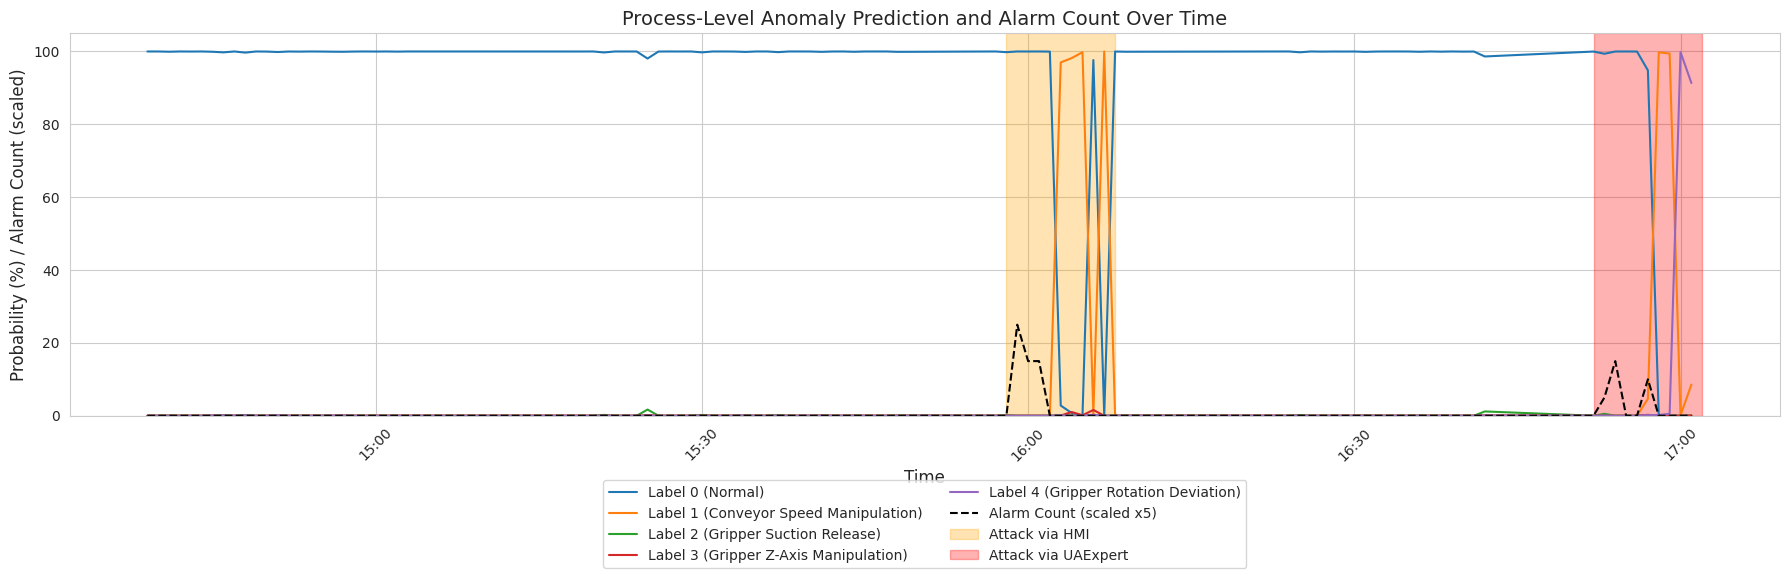

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load your enriched CSV file
df = pd.read_csv('/content/NX_predictions_09May_instances_with_alarms.csv')
df['Minute'] = pd.to_datetime(df['Minute'])

# Descriptive label names
label_desc = {
    0: 'Label 0 (Normal)',
    1: 'Label 1 (Conveyor Speed Manipulation)',
    2: 'Label 2 (Gripper Suction Release)',
    3: 'Label 3 (Gripper Z-Axis Manipulation)',
    4: 'Label 4 (Gripper Rotation Deviation)'
}

# Plot setup
plt.figure(figsize=(18, 6))

# Plot each class probability
for i in range(5):
    plt.plot(df['Minute'], df[f'Prob_Class_{i}'].str.rstrip('%').astype(float),
             label=label_desc[i], linewidth=1.5)

# Plot alarm count (scaled)
plt.plot(df['Minute'], df['alarm_count'] * 5, linestyle='--', color='black',
         label='Alarm Count (scaled x5)', linewidth=1.5)

# Define attack periods
attackviaHMI_start = pd.to_datetime('2025-05-09 15:58:00')
attackviaHMI_end   = pd.to_datetime('2025-05-09 16:08:00')
attackviaUA_start  = pd.to_datetime('2025-05-09 16:52:00')
attackviaUA_end    = pd.to_datetime('2025-05-09 17:02:00')

# Highlight attack periods
plt.axvspan(attackviaHMI_start, attackviaHMI_end, color='orange', alpha=0.3, label='Attack via HMI')
plt.axvspan(attackviaUA_start, attackviaUA_end, color='red', alpha=0.3, label='Attack via UAExpert')

# Axis and formatting
plt.title("Process-Level Anomaly Prediction and Alarm Count Over Time", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Probability (%) / Alarm Count (scaled)", fontsize=12)
plt.ylim(0, 105)
plt.grid(True)
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Legend
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

In [78]:
def explain_process_anomalies(df):
    for _, row in df.iterrows():
        print(f"Time {row['Minute']}")
        print(f"Predicted Label: {row['Predicted_Label']} – {row['Label_Description']}")

        # Show the top prediction probabilities
        probs = [f"Class {i}: {row[f'Prob_Class_{i}']}" for i in range(5)]
        print("Class Probabilities: " + " | ".join(probs))

        # Include alarm info if present
        if row['alarm_count'] > 0:
            print(f"Alarm Count: {int(row['alarm_count'])}, High Priority: {int(row['high_priority_count'])}")
            print(f"Sources: {row['sources']}")
        else:
            print("No alarm raised.")

        print('-' * 60)

# Load CSV
df_proc_log = pd.read_csv('/content/NX_predictions_09May_instances_with_alarms.csv')
df_proc_log['Minute'] = pd.to_datetime(df_proc_log['Minute'])

# Show human-readable log
explain_process_anomalies(df_proc_log)

Time 2025-05-09 14:39:00
Predicted Label: 0 – Label 0: Normal_NoIntervention
Class Probabilities: Class 0: 100.0% | Class 1: 0.0% | Class 2: 0.0% | Class 3: 0.0% | Class 4: 0.0%
No alarm raised.
------------------------------------------------------------
Time 2025-05-09 14:40:00
Predicted Label: 0 – Label 0: Normal_NoIntervention
Class Probabilities: Class 0: 100.0% | Class 1: 0.0% | Class 2: 0.0% | Class 3: 0.0% | Class 4: 0.0%
No alarm raised.
------------------------------------------------------------
Time 2025-05-09 14:41:00
Predicted Label: 0 – Label 0: Normal_NoIntervention
Class Probabilities: Class 0: 99.93% | Class 1: 0.0% | Class 2: 0.06% | Class 3: 0.0% | Class 4: 0.0%
No alarm raised.
------------------------------------------------------------
Time 2025-05-09 14:42:00
Predicted Label: 0 – Label 0: Normal_NoIntervention
Class Probabilities: Class 0: 100.0% | Class 1: 0.0% | Class 2: 0.0% | Class 3: 0.0% | Class 4: 0.0%
No alarm raised.
------------------------------------

In [79]:
def explain_anomalies_only(df):
    filtered = df[(df['Predicted_Label'] != 0) | (df['alarm_count'] > 0)]

    for _, row in filtered.iterrows():
        print(f"Time {row['Minute'].strftime('%Y-%m-%d %H:%M')}")
        print(f"Predicted Label: {row['Predicted_Label']} – {row['Label_Description']}")

        # Format class probabilities
        probs = [
            f"Class {i}: {float(str(row[f'Prob_Class_{i}']).replace('%','')):.2f}%"
            for i in range(5)
        ]
        print("Class Probabilities: " + " | ".join(probs))

        if row['alarm_count'] > 0:
            print(f"Alarm Count: {int(row['alarm_count'])}, High Priority: {int(row['high_priority_count'])}")
            print(f"Sources: {row['sources']}")
        else:
            print("No alarm raised.")

        print("-" * 60)

# Load your CSV (if not already loaded)
df_proc_log = pd.read_csv('/content/NX_predictions_09May_instances_with_alarms.csv')
df_proc_log['Minute'] = pd.to_datetime(df_proc_log['Minute'])

# Call the filtered log function
explain_anomalies_only(df_proc_log)

Time 2025-05-09 15:59
Predicted Label: 0 – Label 0: Normal_NoIntervention
Class Probabilities: Class 0: 100.00% | Class 1: 0.00% | Class 2: 0.00% | Class 3: 0.00% | Class 4: 0.00%
Alarm Count: 5, High Priority: 0
Sources: prov:default:/tag:Conveyor2_Speed:/alm:High Speed Alarm - Conveyor 2
------------------------------------------------------------
Time 2025-05-09 16:00
Predicted Label: 0 – Label 0: Normal_NoIntervention
Class Probabilities: Class 0: 99.99% | Class 1: 0.00% | Class 2: 0.01% | Class 3: 0.00% | Class 4: 0.00%
Alarm Count: 3, High Priority: 0
Sources: prov:default:/tag:Conveyor3_Speed:/alm:High Speed Alarm - Conveyor 3
------------------------------------------------------------
Time 2025-05-09 16:01
Predicted Label: 0 – Label 0: Normal_NoIntervention
Class Probabilities: Class 0: 100.00% | Class 1: 0.00% | Class 2: 0.00% | Class 3: 0.00% | Class 4: 0.00%
Alarm Count: 3, High Priority: 0
Sources: prov:default:/tag:Conveyor3_Speed:/alm:High Speed Alarm - Conveyor 3
------

In [80]:
def generate_anomaly_log(df):
    logs = []
    filtered = df[(df['Predicted_Label'] != 0) | (df['alarm_count'] > 0)]

    for _, row in filtered.iterrows():
        logs.append(f"Time {row['Minute'].strftime('%Y-%m-%d %H:%M')}")
        logs.append(f"Predicted Label: {row['Predicted_Label']} – {row['Label_Description']}")

        probs = [
            f"Class {i}: {float(str(row[f'Prob_Class_{i}']).replace('%','')):.2f}%"
            for i in range(5)
        ]
        logs.append("Class Probabilities: " + " | ".join(probs))

        if row['alarm_count'] > 0:
            logs.append(f"Alarm Count: {int(row['alarm_count'])}, High Priority: {int(row['high_priority_count'])}")
            logs.append(f"Sources: {row['sources']}")
        else:
            logs.append("No alarm raised.")

        logs.append("-" * 60)

    return logs

# Save to file
log_lines = generate_anomaly_log(df_proc_log)
with open("process_anomaly_log_09May_incl_label0_with_alarm.txt", "w") as f:
    for line in log_lines:
        f.write(line + "\n")

The End